In [3]:
# Libraries
library(tidyverse)
library(DataExplorer)
library(mice)
library(factoextra)
library(cluster)
library(arules)
library(caret)

In [15]:
#Load Titanic Dataset
train <- read.csv("/kaggle/input/titanic/train.csv")
str(train)
summary(train)

PassengerId    Survived      Pclass        Name         Sex         Age 
          0           0           0           0           0         177 
      SibSp       Parch      Ticket        Fare       Cabin    Embarked 
          0           0           0           0           0           0

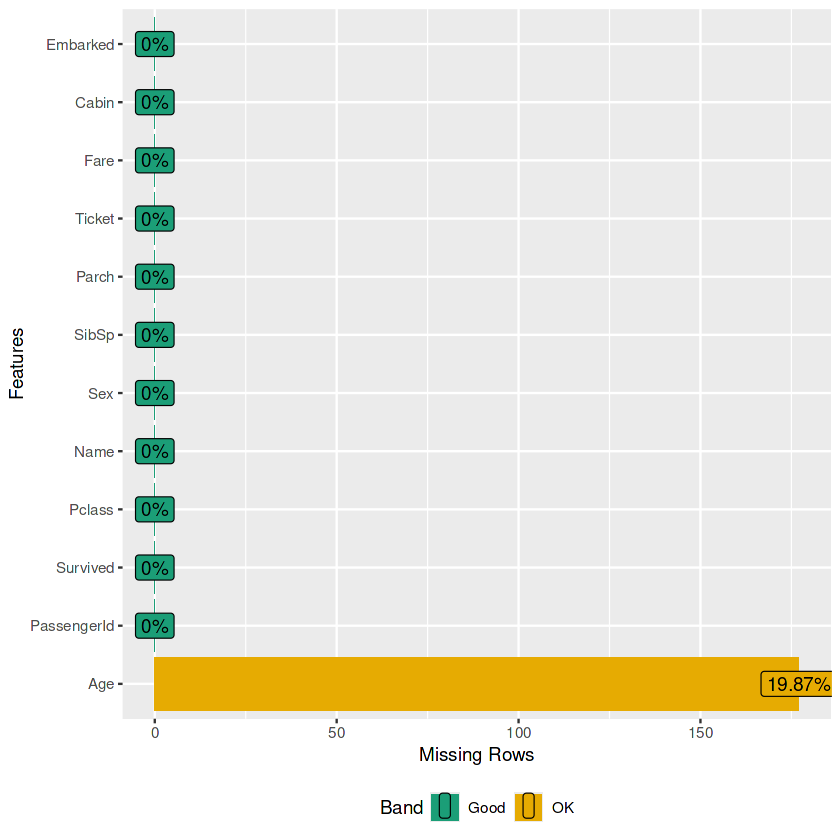

In [13]:
# 1. Detect Common Data Issues

# Missing value summary
plot_missing(train)
colSums(is.na(train))


In [16]:
# Detect special values (Inf, NaN)
sapply(train, function(x) sum(is.infinite(x) | is.nan(x)))

PassengerId    Survived      Pclass        Name         Sex         Age 
          0           0           0           0           0           0 
      SibSp       Parch      Ticket        Fare       Cabin    Embarked 
          0           0           0           0           0           0

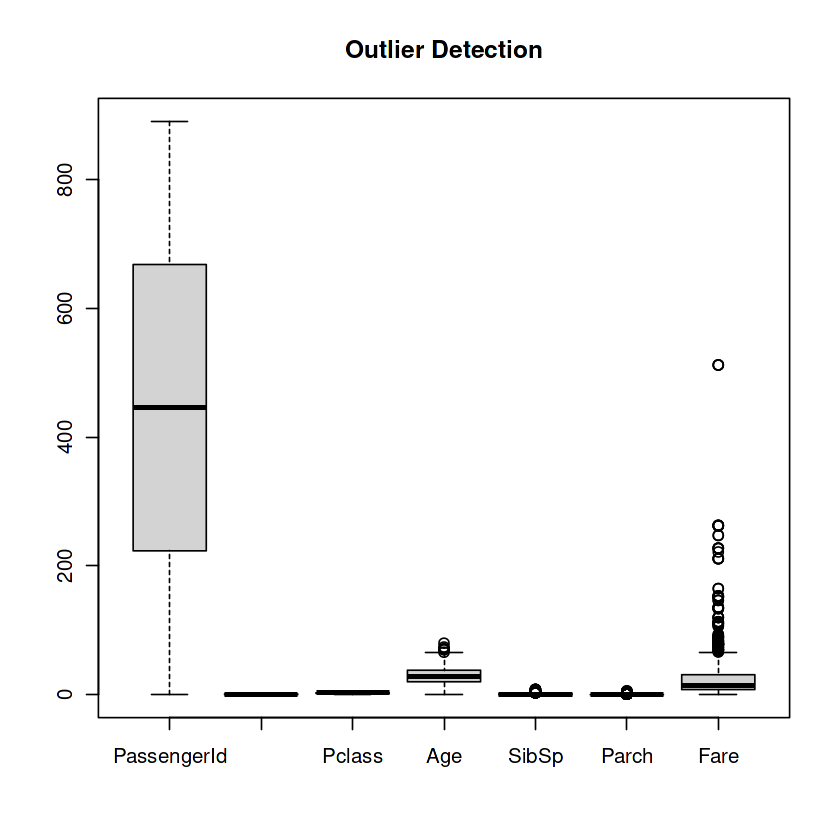

In [17]:
# Detect outliers (for numeric columns)
numeric_data <- train %>% select(where(is.numeric))
boxplot(numeric_data, main="Outlier Detection")

In [18]:
# Check for inconsistent or negative values
sapply(numeric_data, function(x) sum(x < 0))

PassengerId    Survived      Pclass         Age       SibSp       Parch 
          0           0           0          NA           0           0 
       Fare 
          0

In [23]:
# 2. Handling & Transformation
# Impute missing Age values using median
train$Age[is.na(train$Age)] <- median(train$Age, na.rm=TRUE)
# Fill missing Embarked with mode
train$Embarked[is.na(train$Embarked)] <- names(sort(table(train$Embarked), decreasing = TRUE))[1]
# Encode categorical variables
train$Sex <- as.numeric(factor(train$Sex))
train$Embarked <- as.numeric(factor(train$Embarked))
# Drop unused columns
train_clean <- train %>% select(-Name, -Ticket, -Cabin)
# Standardize numeric columns
train_clean <- train_clean %>% mutate(across(where(is.numeric), scale))

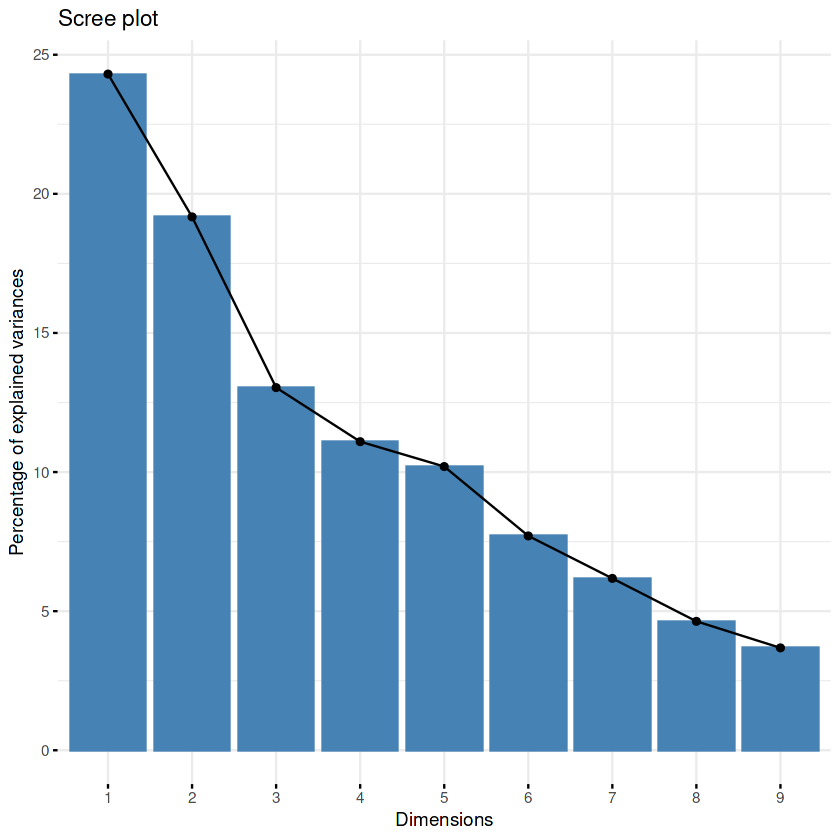

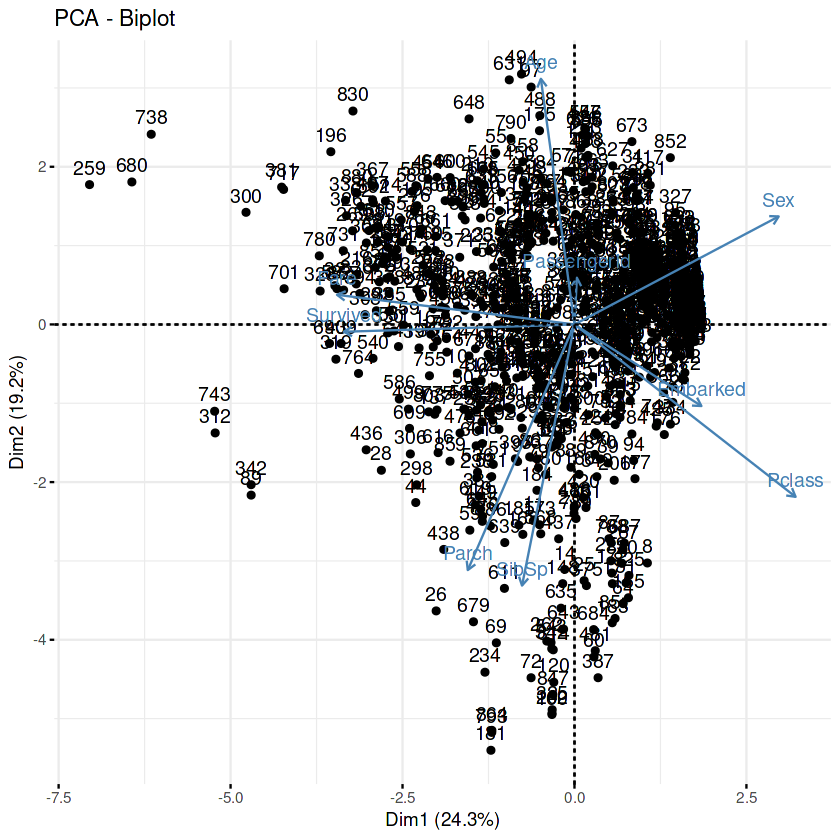

In [25]:
#3. Dimensionality Reduction (PCA)
pca_res <- prcomp(select_if(train_clean, is.numeric), scale = TRUE)
fviz_eig(pca_res)
fviz_pca_biplot(pca_res)

In [26]:
#4. Statistical Significance
# t-test: age difference between survivors & non-survivors
t.test(Age ~ Survived, data=train)


	Welch Two Sample t-test

data:  Age by Survived
t = 1.8966, df = 671.15, p-value = 0.05831
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -0.06126264  3.53486344
sample estimates:
mean in group 0 mean in group 1 
       30.02823        28.29143 


In [27]:
# chi-square test for independence between Sex and Survived
chisq.test(table(train$Sex, train$Survived))


	Pearson's Chi-squared test with Yates' continuity correction

data:  table(train$Sex, train$Survived)
X-squared = 260.72, df = 1, p-value < 2.2e-16


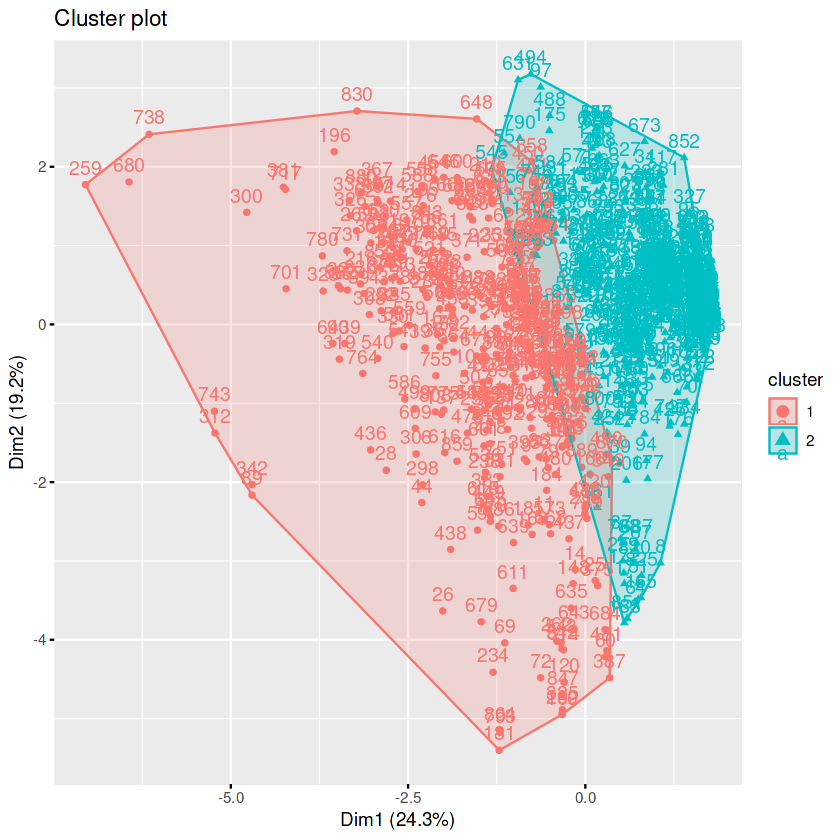

In [28]:
#5. Clustering Analysis
set.seed(123)
km_res <- kmeans(scale(select_if(train_clean, is.numeric)), centers=2, nstart=25)
fviz_cluster(km_res, data = scale(select_if(train_clean, is.numeric)))

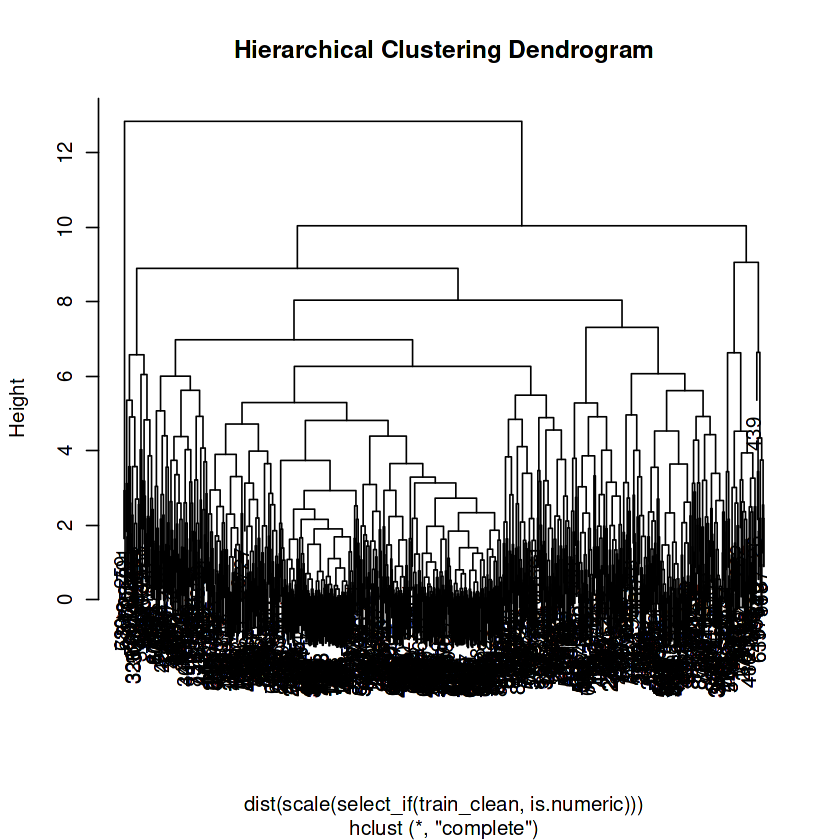

In [29]:
# Hierarchical clustering
hc <- hclust(dist(scale(select_if(train_clean, is.numeric))))
plot(hc, main="Hierarchical Clustering Dendrogram")

In [31]:
#6. Frequent Pattern Mining

# ============================

# Convert to transactions for Apriori
trans_data <- train %>% 
  mutate(across(where(is.numeric), ~cut(., breaks=3, labels=c("Low","Med","High")))) %>%
  mutate(across(where(is.character), as.factor))
transactions <- as(trans_data, "transactions")

rules <- apriori(transactions, parameter=list(supp=0.1, conf=0.8))
inspect(head(rules, 5))

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5     0.1      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 89 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[1745 item(s), 891 transaction(s)] done [0.00s].
sorting and recoding items ... [18 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 7 8 9 done [0.00s].
writing ... [4672 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
    lhs               rhs         support   confidence coverage  lift     count
[1] {}             => {SibSp=Low} 0.9483726 0.9483726  1.0000000 1.000000 845  
[2] {}             => {Fare=Low}  0.9775533 0.9775533  1.0000000 1.000000 871  
[3] {}             => {Parch=Low} 0